<div style="background-color: #D5F5E3; 
            padding: 20px; 
            border: 2px solid #27AE60; 
            border-radius: 10px; 
            text-align: center;">
    <h1 style="color: #196F3D; margin: 0;">ONLINE SHOPPING TREND ANALYSIS</h1>
</div>

<h1 style="color:blue;  text-align: left;">
    PROJECT OVERVIEW
</h1>

This project focuses on analyzing customer purchasing behavior using a shopping trends dataset. The main objective is to extract meaningful insights from the data to understand patterns in consumer preferences, spending habits, and product demand.The dataset includes information such as customer demographics, purchase history, product categories, payment methods, and seasonal trends.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
def load_and_inspect(file_path):
    df = pd.read_csv(file_path)
    print("Dataset Loaded Successfully.")
    print(f"Shape: {df.shape}")
    return df

This function is used to load the dataset from a CSV file and perform a basic inspection. It reads the file using Pandas, displays a confirmation message, and prints the shape of the dataset (number of rows and columns). Finally, it returns the DataFrame for further analysis.

In [47]:
path = r"C:\Users\hp\Downloads\shopping_trends.csv"
df= load_and_inspect(path)

Dataset Loaded Successfully.
Shape: (3900, 19)


In [48]:
import pandas as pd
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping 

In [49]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

This statement displays a concise summary of the DataFrame. The info() function provides important details such as:
Number of rows and columns
Column names
Data types of each column
Number of non-null (non-missing) values
Memory usage

In [50]:
print(df.describe())

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


This statement generates a statistical summary of all numerical columns in the dataset.

In [51]:
def clean_data(df):
    map_dict = {'Yes': True, 'No': False}
    bool_cols = ['Subscription Status', 'Discount Applied', 'Promo Code Used']
    for col in bool_cols:
        df[col] = df[col].map(map_dict)

This function is used to clean and standardize the dataset by converting categorical values into boolean format.

A mapping dictionary (map_dict) is created to convert:
'Yes' → True
'No' → False
The columns:
 Subscription Status
 Discount Applied
 Promo Code Used
are selected for transformation.

In [52]:
if df.isnull().sum().sum() == 0:
        print("No missing values found.")
    


No missing values found.


This code checks whether the dataset contains any missing (null) values.

df.isnull() → Identifies missing values (returns True/False)
.sum() → Counts missing values column-wise
Another .sum() → Gives total missing values in the entire dataset

If the total is 0, it prints:
 "No missing values found."

In [53]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

This code standardizes and cleans the column names of the DataFrame to make them consistent and easy to use.

What each step does:
.str.strip() → Removes leading and trailing spaces
.str.lower() → Converts all column names to lowercase
.str.replace(' ', '_') → Replaces spaces with underscores (_)
.str.replace('(', '') → Removes opening brackets
.str.replace(')', '') → Removes closing brackets

In [54]:
df = df.dropna()

This line removes all rows in the DataFrame that contain missing (null) values.

dropna() → Drops rows with at least one missing value
The cleaned DataFrame is reassigned back to df

In [55]:
df = df.drop_duplicates()

This line removes duplicate rows from the DataFrame.

drop_duplicates() → Identifies and removes rows that are exactly the same across all columns
The cleaned DataFrame is reassigned back to df

In [56]:
import numpy as np

# Select the column to check for outliers
column = 'purchase_amount_usd'

# Step 1: Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Step 3: Handle the outliers (Option A: Filter/Remove them)
df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Step 3: Handle the outliers (Option B: Capping/Winsorizing)
# This replaces outliers with the bound values instead of deleting rows
df[column] = np.where(df[column] > upper_bound, upper_bound, 
             np.where(df[column] < lower_bound, lower_bound, df[column]))

print(f"Outliers handled in '{column}'.")

Lower Bound: -24.0
Upper Bound: 144.0
Outliers handled in 'purchase_amount_usd'.


In [57]:
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].str.strip().str.title()

select_dtypes(include=['object']) → Selects all columns with text/string data
.columns → Gets the list of those column names
Loop through each column:
.str.strip() → Removes extra spaces from the beginning and end
.str.title() → Converts text to title case

In [58]:
categorical_features = ['gender', 'category', 'size', 'season', 'subscription_status', 
                        'payment_method', 'shipping_type', 'discount_applied', 
                        'promo_code_used', 'frequency_of_purchases']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

This code converts selected columns into the categorical data type for better efficiency and analysis.

 it does:
A list of categorical columns is defined
The loop checks if each column exists in the dataset
If present, it converts the column to category type

In [59]:
import pandas as pd
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, include_lowest=True)

print(df[['age', 'age_group']].head())

print(df['age_group'].value_counts())

   age age_group
0   55     46-55
1   19     18-25
2   50     46-55
3   21     18-25
4   45     36-45
age_group
56+      1105
46-55     753
26-35     742
36-45     729
18-25     571
Name: count, dtype: int64


In [60]:
# Define the bin edges and the corresponding labels
# Create the age_group column
# Display the first few rows to verify
# Check the count of customers in each age group

In [61]:
sns.set_theme(style="whitegrid")

def load_and_clean(file_path):
    """Loads the dataset and standardizes headers."""
    df = pd.read_csv(file_path)
    df.columns = [
        col.lower().replace(' ', '_').replace('(', '').replace(')', '') 
        for col in df.columns
    ]
    return df

This code performs data loading and initial cleaning, along with setting a visualization theme.
1. Seaborn Theme
sns.set_theme(style="whitegrid")
Applies a clean white grid style to all visualizations
Improves readability of plots (especially for EDA)

Text(0.5, 1.0, 'Distribution of Customer Age')

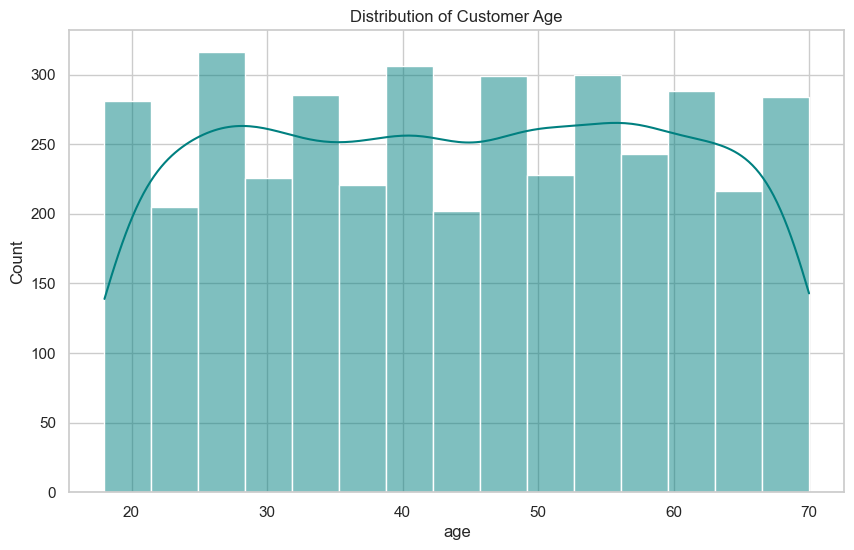

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=15, kde=True, color='teal')
plt.title('Distribution of Customer Age')


The histogram shows the distribution of customer ages, highlighting the most common age group and overall spread. This helps in identifying the target audience and understanding customer demographics.”

Text(0.5, 1.0, 'Purchase Amount Distribution by Category')

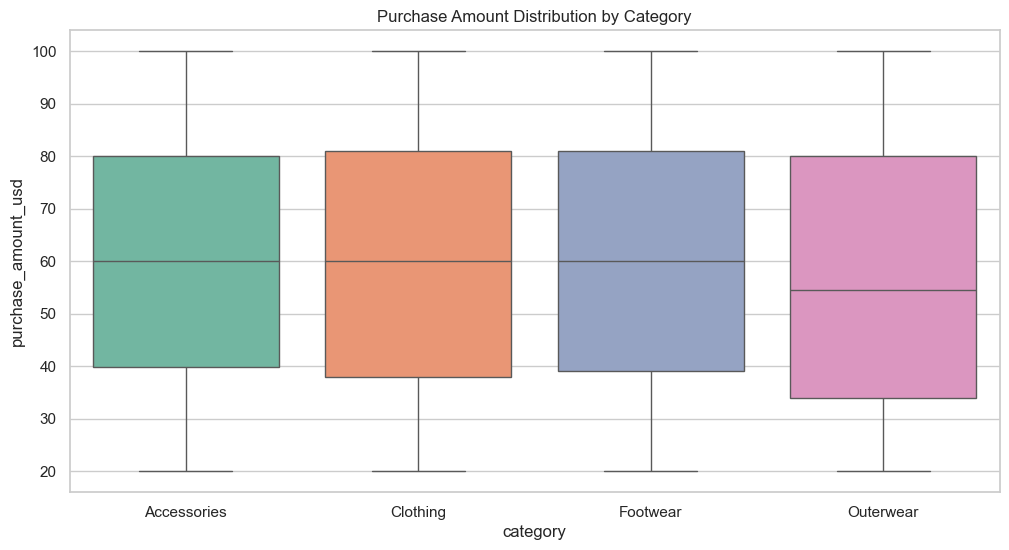

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='category', y='purchase_amount_usd', data=df, palette='Set2',hue= 'category')
plt.title('Purchase Amount Distribution by Category')


“From the box plot, we can observe differences in customer spending across categories. Some categories show higher median purchase values, indicating greater customer spending, while others show higher variability and outliers, suggesting inconsistent purchasing behavior.”

Text(0.5, 1.0, 'Total Revenue by Season')

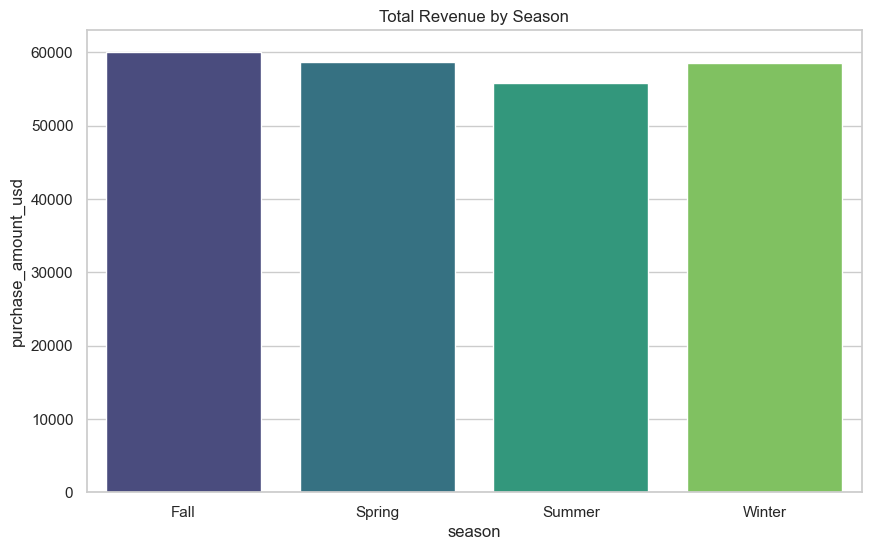

In [64]:
plt.figure(figsize=(10, 6))
seasonal_revenue = df.groupby('season',observed='false')['purchase_amount_usd'].sum().reset_index()
sns.barplot(x='season', y='purchase_amount_usd', data=seasonal_revenue, palette='viridis' ,hue ='season' )
plt.title('Total Revenue by Season')


The bar chart shows total revenue across different seasons, highlighting peak and low sales periods. This helps businesses understand seasonal demand and plan inventory, marketing, and promotional strategies effectively.

Text(0.5, 1.0, 'Subscription Status Distribution')

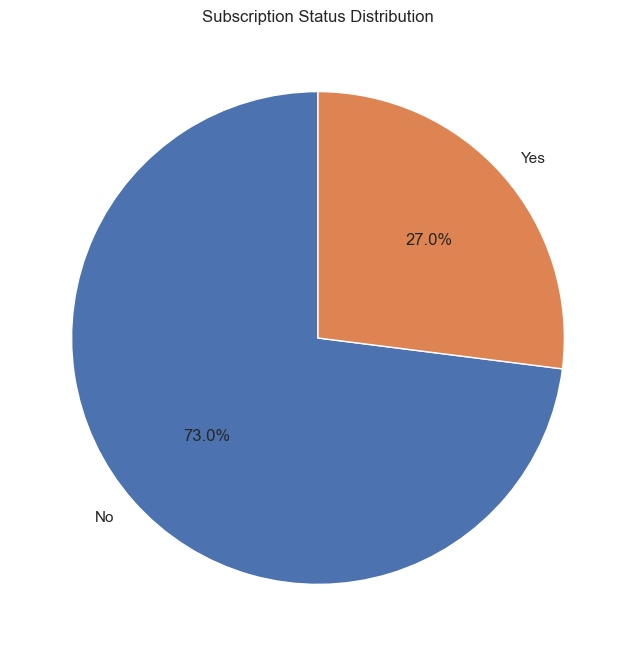

In [65]:
plt.figure(figsize=(8, 8))
sub_counts = df['subscription_status'].value_counts()
plt.pie(sub_counts, labels=sub_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Subscription Status Distribution')


The pie chart illustrates the distribution of customers based on subscription status, helping to identify the proportion of loyal versus non-loyal customers and enabling businesses to improve retention strategies.

Text(0.5, 1.0, 'Age vs. Purchase Amount')

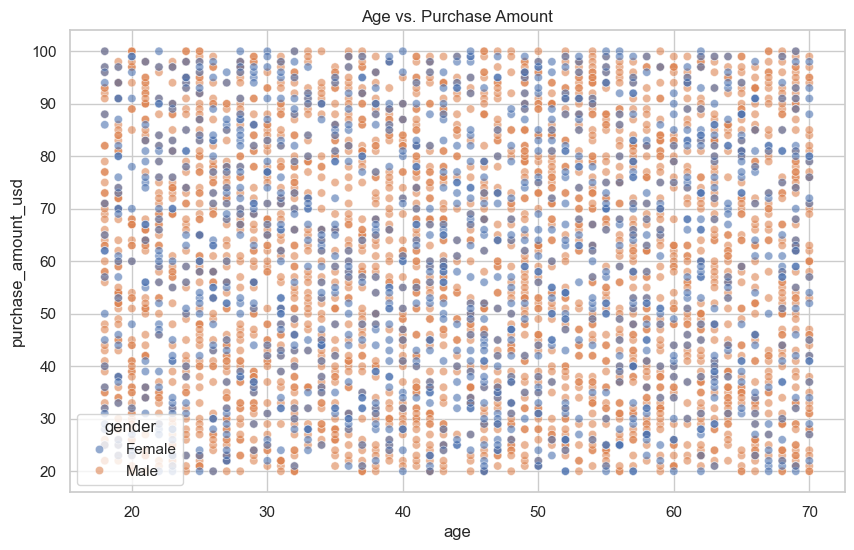

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='purchase_amount_usd', hue='gender', data=df, alpha=0.6)
plt.title('Age vs. Purchase Amount')


The scatter plot shows the relationship between age and purchase amount, along with gender-based differences. It helps identify spending patterns, high-value customers, and whether age influences purchasing behavior.

In [69]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

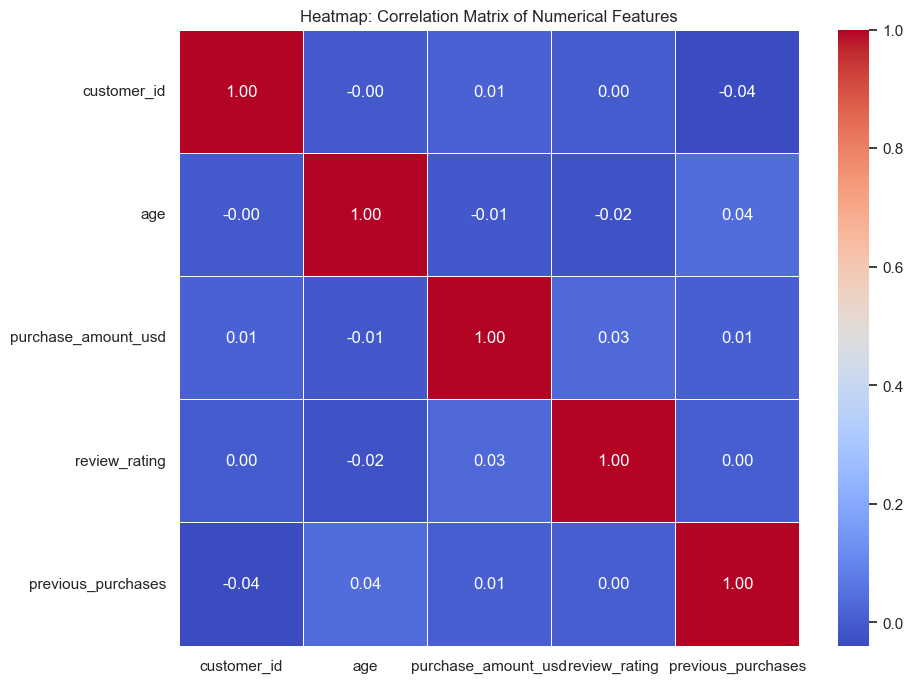

In [70]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Heatmap: Correlation Matrix of Numerical Features')
plt.show()

The heatmap visualizes the relationships between numerical variables, helping identify strong correlations, key influencing factors, and potential redundancies in the dataset

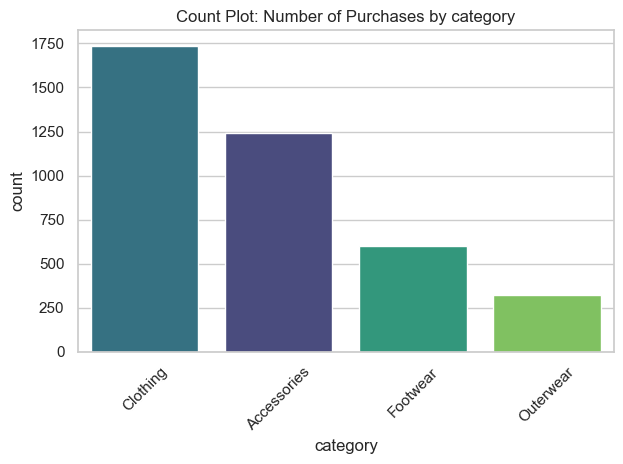

In [71]:
category_order = df['category'].value_counts().index
sns.countplot(data=df, x='category', order=category_order, palette='viridis',hue='category')

plt.title('Count Plot: Number of Purchases by category')
plt.xlabel('category')
plt.ylabel('count')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

The count plot shows the frequency of purchases across different categories, helping identify the most and least popular products and supporting better inventory and marketing decisions.

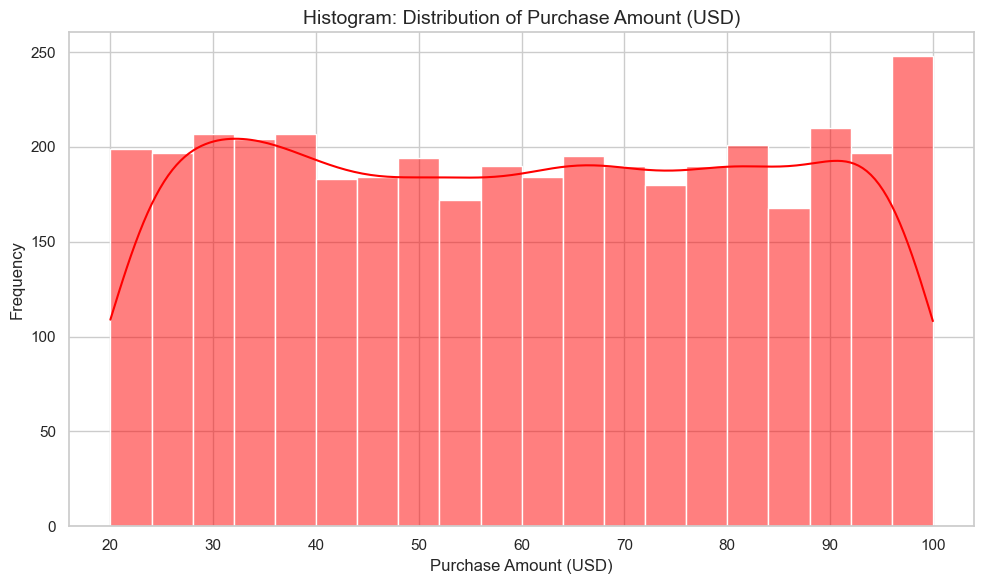

In [72]:
plt.figure(figsize=(10, 6))
sns.histplot(df['purchase_amount_usd'], kde=True, color='red', bins=20)
plt.title('Histogram: Distribution of Purchase Amount (USD)', fontsize=14)
plt.xlabel('Purchase Amount (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()




The histogram shows the distribution of purchase amounts, highlighting common spending ranges, variability, and the presence of high-value customers, which helps in customer segmentation and pricing strategies.

In [73]:
age_spending=df.groupby('age')[ 'purchase_amount_usd'].mean().reset_index()

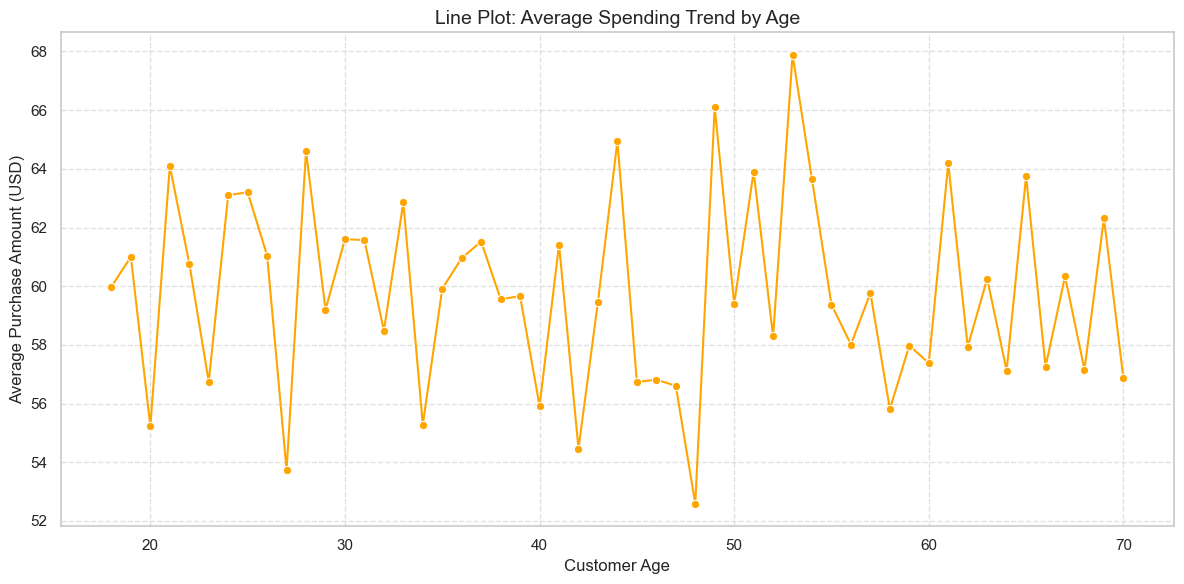

In [74]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=age_spending, x='age', y='purchase_amount_usd', marker='o', color='orange')
plt.title('Line Plot: Average Spending Trend by Age', fontsize=14)
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Average Purchase Amount (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout()
plt.show()

The line plot shows how average purchase amount varies with age, helping identify peak spending age groups and overall trends in customer purchasing behavior

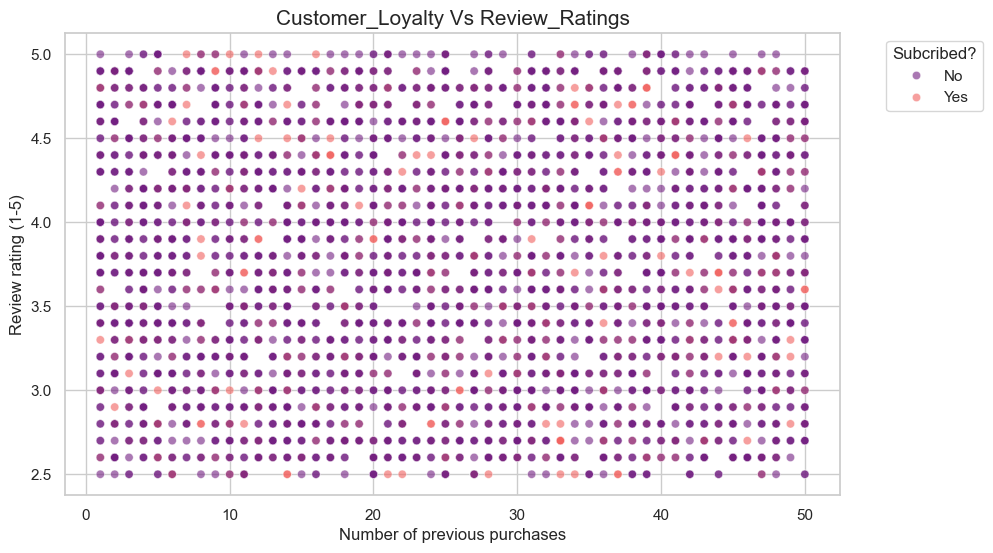

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='previous_purchases' , y='review_rating',hue='subscription_status',
    palette='magma',alpha=0.6)
plt.title('Customer_Loyalty Vs Review_Ratings', fontsize=15)
plt.xlabel('Number of previous purchases', fontsize=12)
plt.ylabel('Review rating (1-5)',fontsize=12)
plt.legend(title='Subcribed?',bbox_to_anchor=(1.05 ,1), loc='upper left')
plt.show()

The scatter plot highlights the relationship between customer loyalty and review ratings, along with subscription status. It helps identify satisfaction trends among repeat customers and evaluate the impact of subscriptions on customer behavior.

Text(0, 0.5, 'Purchase Amount (USD)')

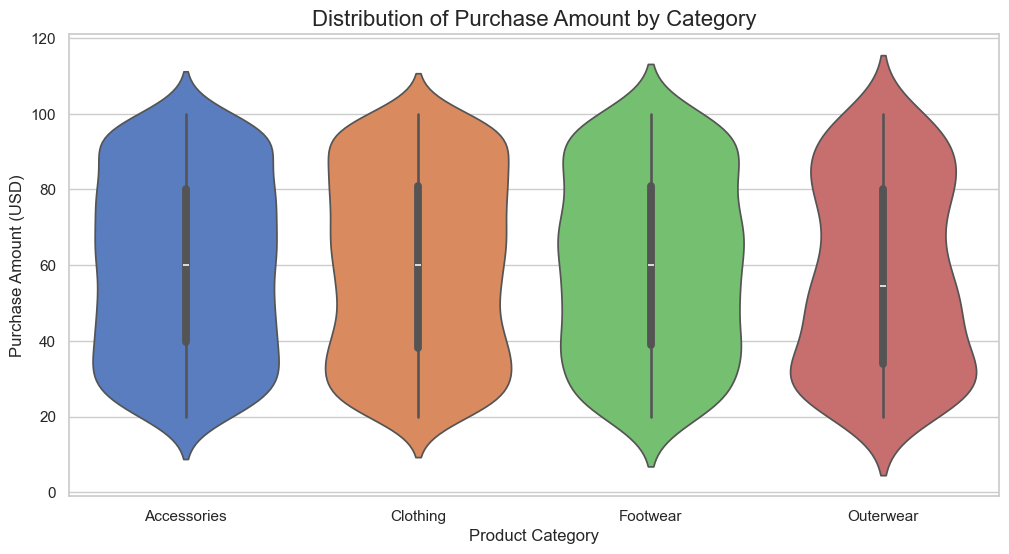

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the Violin Plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='category', y='purchase_amount_usd', data=df, hue='category', palette='muted', legend=False)

# Add titles and labels
plt.title('Distribution of Purchase Amount by Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Purchase Amount (USD)', fontsize=12)



A "Bulgy" Violin: If the violin for "Clothing" is very wide at the $50 mark, it means a vast majority of customers spend exactly around $50 on clothes.

A "Long and Skinny" Violin: If the violin for "Accessories" is very long but thin, it means prices are spread out widely (some very cheap, some very expensive), but there isn't one specific price point that most people stick to.

Multiple Humps: If a violin has two wide sections (like a figure-8), it suggests a bimodal distribution. For example, you might have one group of customers buying budget items and another group buying premium items, with very few people buying in the middle.

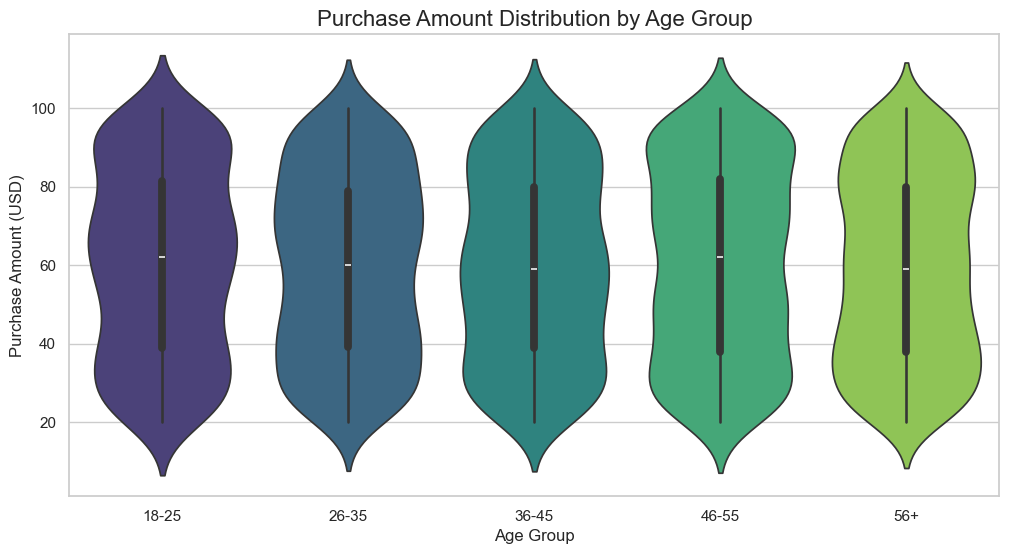

In [77]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='age_group', y='purchase_amount_usd', data=df, palette='viridis', hue='age_group', legend=False)

plt.title('Purchase Amount Distribution by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Purchase Amount (USD)', fontsize=12)

plt.savefig('age_group_spending_violin.png')

The 18-25 group has a higher count of purchases, the 46-55 group shows a higher density in the $80-$100 range, making them the primary target for premium product marketing.

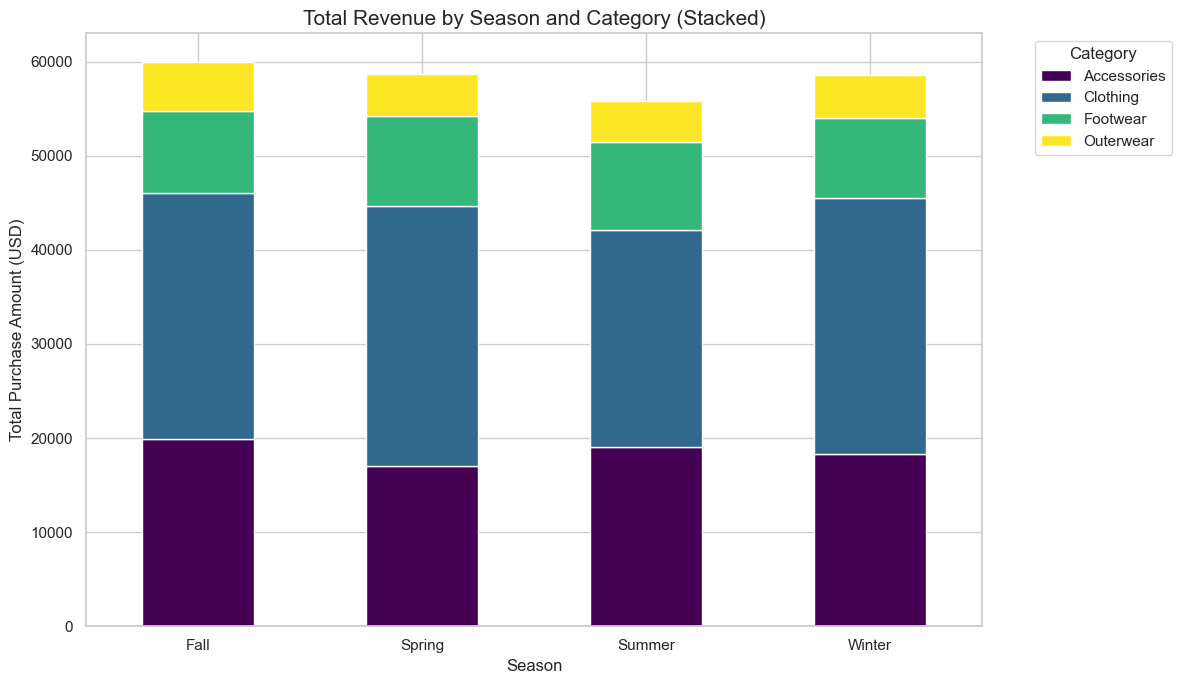

In [78]:
# Plotting
stacked_data.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Total Revenue by Season and Category (Stacked)', fontsize=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Purchase Amount (USD)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The stacked bar chart shows how total revenue is distributed across seasons and categories, helping identify key revenue drivers and seasonal demand patterns for better business planning

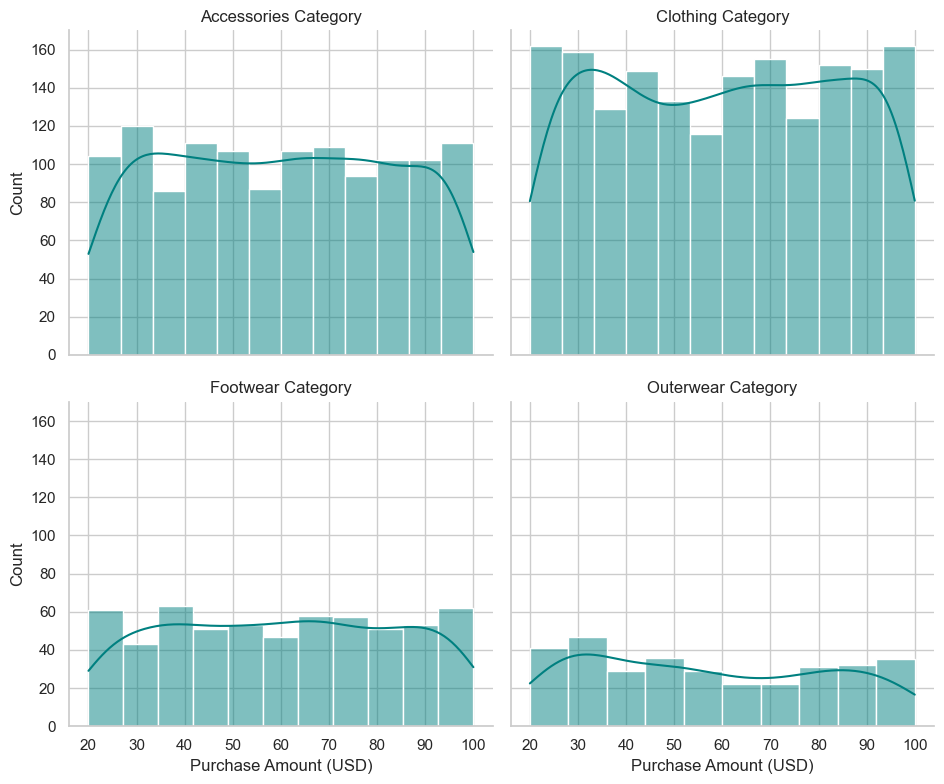

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize the grid: One column for each 'category'
g = sns.FacetGrid(df, col="category", col_wrap=2, height=4, aspect=1.2)

# 2. Map a plot type to the grid (e.g., a histogram of purchase amounts)
g.map(sns.histplot, "purchase_amount_usd", kde=True, color="teal")

# 3. Add titles and spacing
g.set_axis_labels("Purchase Amount (USD)", "Count")
g.set_titles("{col_name} Category")
plt.tight_layout()
plt.show()

The FacetGrid visualization shows the distribution of purchase amounts for each category separately, enabling comparison of spending behavior across categories and helping identify key revenue-driving segments.

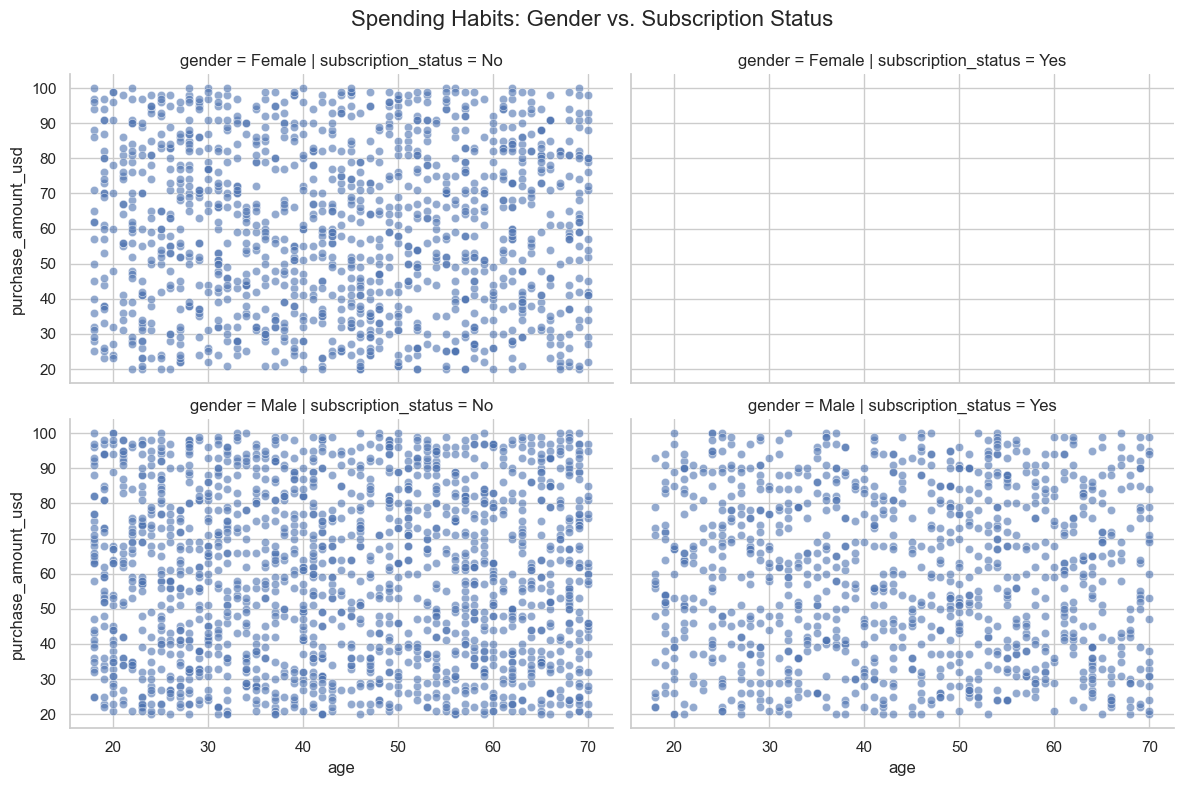

In [80]:
# Create a grid where rows are 'gender' and columns are 'subscription_status'
g = sns.FacetGrid(df, row="gender", col="subscription_status", height=4, aspect=1.5)

# Map a scatter plot to see Age vs Purchase Amount in each segment
g.map(sns.scatterplot, "age", "purchase_amount_usd", alpha=0.6)

# Add a main title
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Spending Habits: Gender vs. Subscription Status', fontsize=16)

plt.show()

<h2 style="color:blue;">INSIGHTS</h2>

1. Customer Age Influences Spending,
      Certain age groups show higher average purchase amounts.
     👉 Helps identify the target customer segment
2. Popular Product Categories Drive Sales,
     Some categories have higher purchase frequency and revenue
     👉 Indicates customer preferences and high-demand products.
3. Seasonal Trends Affect Revenue,
      Sales vary across seasons with peak and low periods
     👉 Useful for inventory and marketing planning.
4. Subscription Improves Customer Loyalty
      Subscribed customers tend to:
      Purchase more frequently
      Show higher engagement
     👉 Indicates strong customer retention.
5. Spending Behavior Varies Across Customers,
      Presence of high-value customers and outliers
      👉 Opportunity to target premium segments.
6. Weak/Moderate Correlation Between Features
      Not all variables strongly impact purchase amount,
      👉 Suggests multiple factors influence buying behavior.

<h2 style="color:blue;">CONCLUSION</h2>

In [ ]:
 
The project demonstrates how data-driven decisions can optimize inventory planning,
refine marketing strategies toward high-value segments, and improve customer retention 
through a better understanding of the subscription model's impact.